# 03 - Cross-Exchange Comparison
Compare spread/depth distributions and identify liquidity gap across exchanges.

In [1]:
import sys
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Add parent dir to sys.path to import framework
sys.path.append(os.path.abspath('..'))

from framework.metrics import compute_spread_metrics, compute_depth_profile

sns.set_theme(style="whitegrid")

Loaded 2 rows for Tokocrypto
Loaded 2 rows for Reku


/var/folders/s1/c7bm9y8s7_59r1jmjvbtwdym0000gn/T/ipykernel_35158/1645336304.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='exchange_name', y='spread_pct', palette='Set2')


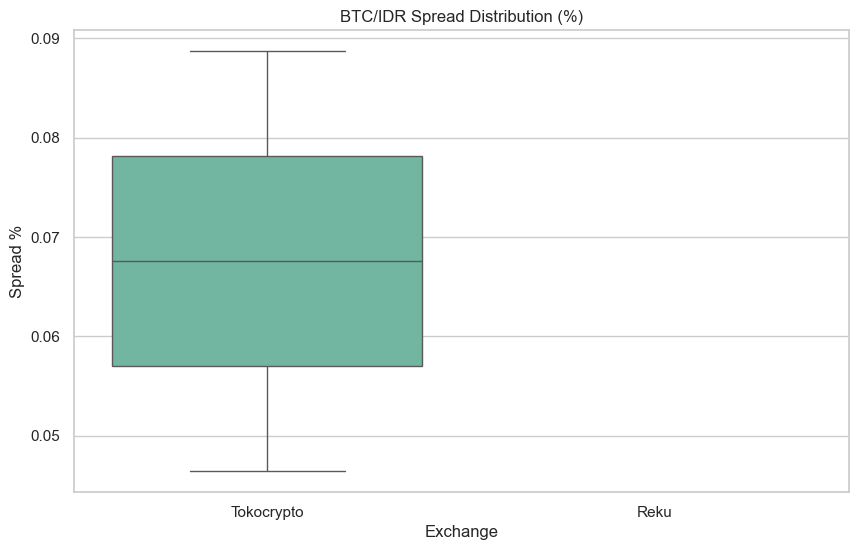

In [2]:
files = {
  'Tokocrypto': '../data/raw/orderbook_tokocrypto_BTC_IDR.csv',
  'Reku': '../data/raw/orderbook_reku_BTCIDR.csv'
}

dfs = []
for name, path in files.items():
    if os.path.exists(path):
        try:
            d = pd.read_csv(path)
            if len(d) > 0:
                d_metrics = compute_spread_metrics(d)
                d_metrics['exchange_name'] = name
                dfs.append(d_metrics)
                print(f"Loaded {len(d)} rows for {name}")
        except Exception as e:
            print(f"Error loading {name}: {e}")
    else:
        print(f"Warning: Path not found {path}")

if dfs:
    plot_df = pd.concat(dfs, ignore_index=True)
    
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=plot_df, x='exchange_name', y='spread_pct', palette='Set2')
    plt.title('BTC/IDR Spread Distribution (%)')
    plt.ylabel('Spread %')
    plt.xlabel('Exchange')
    plt.show()
else:
    print("No data available for comparison.")

In [3]:
def compare_depth(dfs, threshold=1.0):
    depth_results = []
    for d in dfs:
        name = d['exchange_name'].iloc[0]
        dp = compute_depth_profile(d, thresholds=[threshold])
        avg_depth = dp[[f'bid_depth_{threshold:.1f}pct_notional', f'ask_depth_{threshold:.1f}pct_notional']].mean(axis=1).mean()
        depth_results.append({'Exchange': name, f'Avg Depth @ {threshold}% (Notional)': avg_depth})
    return pd.DataFrame(depth_results)

if dfs:
    depth_df = compare_depth(dfs)
    display(depth_df)
else:
    print("No depth data to compare.")

,Exchange,Avg Depth @ 1.0% (Notional)
0,Tokocrypto,3.773322e+08
1,Reku,0.000000e+00
